# -------------- Auxiliar 2 --------------

## AS4501-1 

Profs. Valentino Gonzalez, Francisco Förster

Author: P. Cáceres Burgos, based from Melissa Fuentalba's work

# ------------------------------------------


# Bayes Theorem

<font size='3'> This theorem is a mathematical formulae that helps us determine the conditional probability of an event based on our previous knowledge and new evidence. 

$\textbf{X}$: Observed data.

$\hat\theta$: Parameter vector.

$\textbf{M}$: Model.

$$ \large P(\hat\theta|X,M) = \frac{P(X|\hat\theta,M) P(\hat\theta|M)}{P(X|M)} $$

$\bigstar$ $P(X|\hat\theta,M)$ is the likelihood function, it describes the joint probability of the observed data as a function of the parameters of the chosen statistical model.

$\bigstar$  $P(\hat\theta|M)$ is the prior, an initial probability distribution that is assigned to the parameters, without further evidence.

$\bigstar$  $P(X|M)$ is the marginalized distribution of the dataset over all parameter values in model M, also called marginal likelihood or model evidence BUT this parameter can be very hard to compute in many cases. For this reason, we disregard it and uses as a normalization factor.

$\bigstar$  $P(\hat\theta|X,M)$ is the posterior distribution (what we want).

# Statistical Inference:

<font size='3'> Is the process of using data analysis to infer properties of an underlying probability distribution. This analysis helps to infer the properties of a populations, by testing hypothesis and deriving estimates. We assume that the observed data set are samples from a larger population. 


## Bayesian Inference over Frequentist Statistics

<font size='3'> There are 2 main approaches to statistical inference, Frequentist and Bayesian, differing in their interpretation of uncertainty. 

<font size='3'> The frequentist approach deals with long-run probabilities (how probable is this data set given the null hypothesis), whereas the Bayesian approach deals with the probability of a hypothesis given a particular data set.


<font size='3'> Bayesian statistics advantages:

<font size='3'> - Bayesian analysis incorporates prior information into the analysis, whereas a frequentist analysis is purely driven by the data.

<font size='3'> - Bayesian estimates provide a posterior distribution from which we can compute a number of statistics.

<font size='3'> For the following example, we will try to do a Markov Chain Monte Carlo using a friendly library called PyMC. For this, its ***very advisable*** to create a conda environment :)



 <font size='3'> These are the steps to create a conda environment that can be used as a Jupyter kernel


> python3 -m venv ~/astroinf_env  

> source ~/astroinf_env/bin/activate  

> pip install --upgrade pip  

> pip install jupyter ipykernel pymc corner astropy

> python -m ipykernel install --user --name=astroinf_env --display-name "Python (astroinf_env)"


In [1]:
## Importing libraries
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import corner
import astropy.units as u 
import astropy.cosmology
import dill

# Practical example

<font size='3'> The data we will use consists of the optical spectrum of the galaxy J100903.23-001337.4, obtained from SDSS DR16 using single-fiber spectroscopy. Previously, we modeled the galaxy's stellar continuum using the STARLIGHT software (Cid Fernandes et al. 2005, 2007) and subtracted it to obtain the normalized spectrum for analysis.

In [8]:
path_raw = 'Data_AUXs/spec-0270-51909-0265.txt'
path_processed = 'Data_AUXs/spec-0270-51909-0265_parsed.txt'

flux_norm = 4.476865E+01  * 1e-17 * u.erg / u.s / u.cm**2 / u.Angstrom 
raw_specta_sdss = pd.read_csv(path_raw ,names = ['lamb', 'raw_flux', 'raw_error'], skiprows=1, sep=' ')
stellar_fit_spectra = pd.read_csv(path_processed, names = ['lamb', 'flux', 'f_syn', 'wei'], sep=' ', skiprows=1)

Joined_data = pd.merge(raw_specta_sdss, stellar_fit_spectra, on="lamb")

gal_flux = Joined_data.flux
stellar_continuum_flux = Joined_data.f_syn

flux_sub = gal_flux - stellar_continuum_flux
s_to_n = Joined_data.raw_flux/ Joined_data.raw_error
error_flux = gal_flux/s_to_n

lamb = Joined_data.lamb

Text(0, 0.5, 'Flux / Flux_norm [$erg s^{-1} cm^{-2} \\AA^{-1}$]')

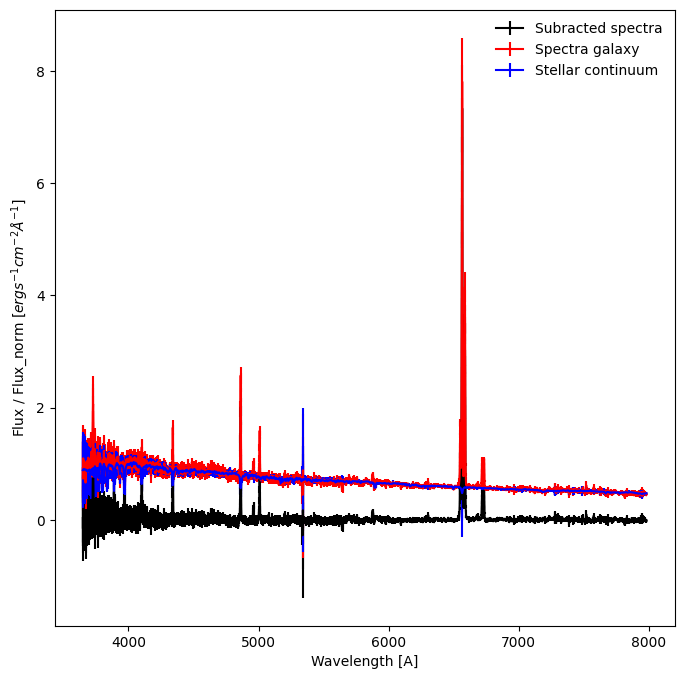

In [9]:
plt.figure(figsize=(8,8))
plt.errorbar(lamb, flux_sub, yerr = error_flux, color='k', label='Subracted spectra')
plt.errorbar(lamb, gal_flux, yerr = error_flux, color='r', label='Spectra galaxy')
plt.errorbar(lamb, stellar_continuum_flux , yerr = error_flux, color='b', label='Stellar continuum')
plt.legend(frameon=False)
plt.xlabel('Wavelength [A]')
plt.ylabel('Flux / Flux_norm [$erg s^{-1} cm^{-2} \\AA^{-1}$]')

<font size='3'> We are interested in detecting and fitting the broad H$\alpha$ (6564.614 A) line, which is an observational signature for type I AGNs. Generally, the shape for emission lines can be described with a Gaussian.  Lets take a look at our data: 


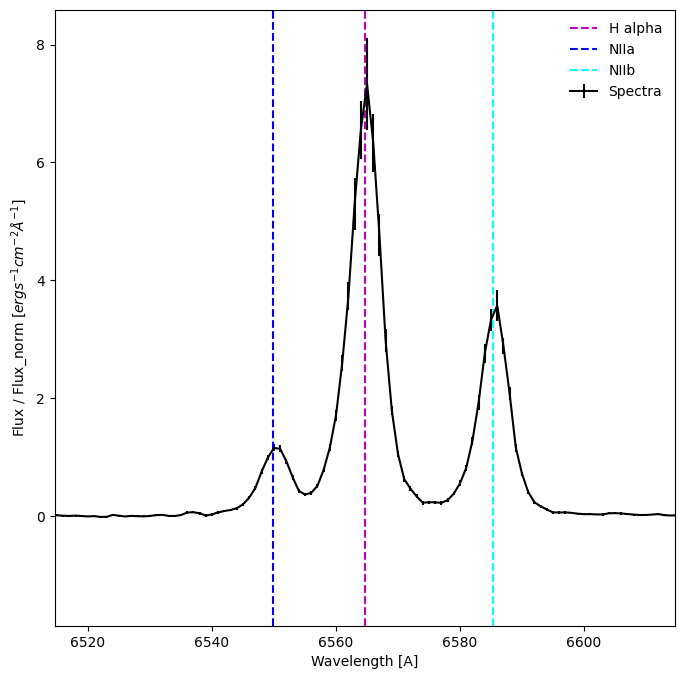

In [10]:
#z = 0.04466367

Ha_center = 6564.614 # A 
NIIa_center = 6549.86
NIIb_center = 6585.27

plt.figure(figsize=(8,8))
plt.errorbar(lamb, flux_sub, yerr = error_flux, color='k', label='Spectra')
plt.xlim(Ha_center - 50, Ha_center + 50)

plt.axvline(Ha_center, ls ='--', label= 'H alpha', color='m')
plt.axvline(NIIa_center, ls ='--', label= 'NIIa', color='blue')
plt.axvline(NIIb_center, ls ='--', label= 'NIIb', color='cyan')

plt.xlabel('Wavelength [A]')
plt.ylabel('Flux / Flux_norm [$erg s^{-1} cm^{-2} \\AA^{-1}$]')
plt.legend(frameon=False)

<font size='3'> In this plot we observe 3 emission lines: 
    
<font size='3'>- The Halpha
    
<font size='3'>- The 2 NII doublet.
    
<font size='3'>These three correspond to narrow emission lines which have the property of sharing the same widths within each other. We will also fit another emission line, centered at H alpha, that will have a broader width and a smaller amplitude than its Narrow component. 
    
    
<font size='3'>The function we will fit will be the following:  
    
<font size='3'>
<font size='3'>
<font size='3'>
\begin{equation}   
  F(\lambda) = G(A_{H \alpha}, \lambda_{H \alpha}, \sigma_{narrow}) + G(A_{NIIa}, \lambda_{NIIa}, \sigma_{narrow}) + G(A_{NIIb}, \lambda_{NIIb}, \sigma_{narrow}) + G(A_{H \alpha Broad}, \lambda_{H \alpha}, \sigma_{broad})
\end{equation}
    
<font size='3'>
    
    
<font size='3'>Where G corresponds to a gaussian function 
    
<font size='3'>
\begin{equation}
G(A, \mu, \sigma) = A \times exp( (\lambda - \mu)^2 / 2\sigma^2)
\end{equation}
<font size='3'>
    
<font size='3'>And:

    
    
<font size='3'>$\sigma_{narrow}$ : Standard deviation of narrow line  
<font size='3'>$\sigma_{broad}$  : Standard deviation of broad line  
<font size='3'>$ A_{line}$: Flux amplitude of the corresponding line  
<font size='3'>$\lambda_{line}$  : Wavelength position of the corresponding line
<font size='3'>    

In [11]:
# We define our model function here 

def gaussian(x, a, x0, sigma):
    """
    gaussian function
    
    input:
    ------
    x : [float/ndarray] x axis
    a : [float] amplitude
    x0 : [float] mean
    sigma : [float] sigma
    
    output:
    -------
    
    [float/ndarray]
    
    """
    return a*np.exp(-(x-x0)**2/(2*sigma**2))


def cuatruple_gaussian(x, a1, x01, sigma, a2, x02, a3, x03, a4, x04, sigma2):
    """
    Cuatruple gaussian function with the 3 equal sigmas
    
    input:
    ------
    x : [float/ndarray] x axis
    a1 : [float] amplitude 1
    x01 : [float] mean 1
    sigma1 : [float] sigma 1
    a2 : [float] amplitude 2
    x02 : [float] mean 2
    sigma2 : [float] sigma 2
    a3 : [float] amplitude 3
    x03 : [float] mean 3
    sigma3 : [float] sigma 3
    
    
    output:
    -------
    
    [float/ndarray]
    
    """
    return gaussian(x, a1, x01, sigma) + gaussian(x, a2, x02, sigma) + gaussian(x, a3, x03, sigma) + gaussian(x, a4, x04, sigma2)

### Prior

<font size='3'> For the prior distribution of the parameters we are going to use:

| $Parameter$ | $Prior$ | 
| --- | --- | 
| $A_{H \alpha}$ | $U (0, F_{max} [\lambda_{H \alpha} -4;\lambda_{ H \alpha} +4 ])$|
| $A_{H \alpha Broad}$ | $U (0, F_{max} [\lambda_{H \alpha} -4;\lambda_{ H \alpha} +4 ])$| 
| $A_{NIIa}$ | $U (0, F_{max} [\lambda_{NIIa} -4;\lambda_{NIIa} +4 ])$| 
| $A_{NIIb}$ | $U (0, F_{max} [\lambda_{NIIb} -4;\lambda_{NIIb} +4 ])$| 
| $\lambda_{H \alpha Broad}$ | $U (\lambda_{H \alpha} -4;\lambda_{ H \alpha} +4) $ |   
| $\sigma_{narrow}$ | $U (1, 5)$ |
| $\sigma_{broad}$ | $U (2, 20)$ |
| $\Delta \lambda$ | $ U(-2, 2)$ |

In [12]:
Fmax_Ha = np.max(flux_sub[(lamb < Ha_center+4) & (lamb> Ha_center-4)])
Fmax_NIIa = np.max(flux_sub[(lamb < NIIa_center+4) & (lamb> NIIa_center-4)])
Fmax_NIIb = np.max(flux_sub[(lamb < NIIb_center+4) & (lamb> NIIb_center-4)])

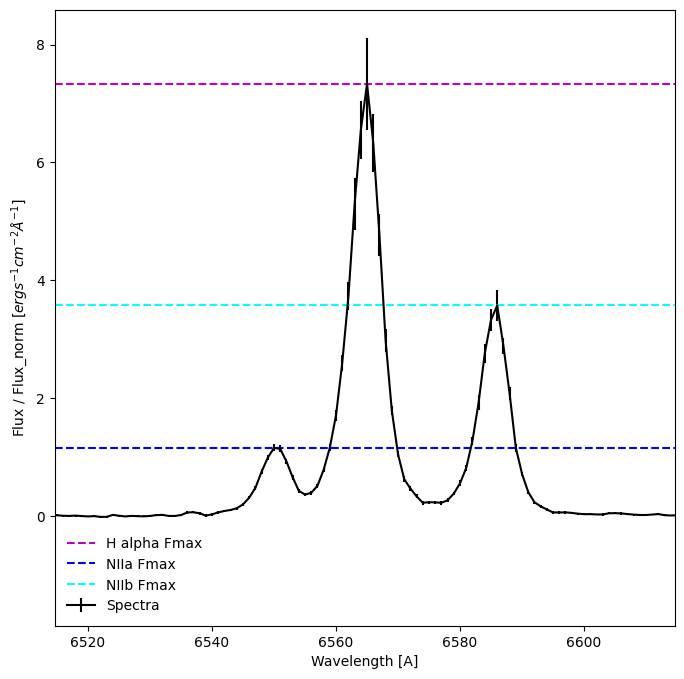

In [14]:
plt.figure(figsize=(8,8))
plt.errorbar(lamb, flux_sub, yerr = error_flux, color='k', label='Spectra')
plt.xlim(Ha_center - 50, Ha_center + 50)

plt.axhline(Fmax_Ha, ls ='--', label= 'H alpha Fmax', color='m')
plt.axhline(Fmax_NIIa, ls ='--', label= 'NIIa Fmax', color='blue')
plt.axhline(Fmax_NIIb, ls ='--', label= 'NIIb Fmax', color='cyan')

plt.xlabel('Wavelength [A]')
plt.ylabel('Flux / Flux_norm [$erg s^{-1} cm^{-2} \\AA^{-1}$]')
plt.legend(frameon=False)

In [15]:
model = pm.Model()

# 1) Model
with model as MyModel:
    
    # 2) Prior    
    A_Ha = pm.Uniform('A_Ha', 0 , Fmax_Ha)
    A_HaBroad = pm.Uniform('A_HaBroad', 0 , Fmax_Ha)
    A_NIIa = pm.Uniform('A_NIIa', 0 , Fmax_NIIa)
    A_NIIb = pm.Uniform('A_NIIb', 0 , Fmax_NIIb)
    
    sigma_narrow = pm.Uniform('sigma_narrow', 1, 5)
    sigma_broad  = pm.Uniform('sigma_broad', 2, 20)
    delta_lambda = pm.Uniform('delta_lambda', -2, 2) 
    HaBroad_center = pm.Uniform('HaBroad_center', Ha_center-4, Ha_center+4)
    
    Ha_shifted = Ha_center + delta_lambda
    NIIa_shifted = NIIa_center + delta_lambda
    NIIb_shifted = NIIb_center + delta_lambda
    
    
    # 3) Expected value of outcome: 
    w = np.asarray(lamb)
    
    function = A_Ha*np.exp(-(w-Ha_shifted)**2/(2*sigma_narrow**2)) + A_HaBroad*np.exp(-(w-HaBroad_center)**2/(2*sigma_broad**2)) +  A_NIIa*np.exp(-(w-NIIa_shifted)**2/(2*sigma_narrow**2)) +  A_NIIb*np.exp(-(w-NIIb_shifted)**2/(2*sigma_narrow**2))
    
    # 4) Likelihood
    L = pm.Normal('likelihood', function, sigma = error_flux, observed= flux_sub)

    # 5) Step
    step = pm.NUTS(target_accept = 0.95)
    
    # 6) Trace
    chains = 4
    trace = pm.sample(draws=1500, step=step, chains=chains, tune=500, return_inferencedata=True)


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A_Ha, A_HaBroad, A_NIIa, A_NIIb, sigma_narrow, sigma_broad, delta_lambda, HaBroad_center]


Sampling 4 chains for 500 tune and 1_500 draw iterations (2_000 + 6_000 draws total) took 14 seconds.


### 1) with model as MyModel

<font size='3'> Creates a new Model object which is a container for the model random variables. Using $\textbf{with}$ creates a context manager, with our basic_model as the context, that includes all statements until the indented block ends. This means all PyMC objects introduced in the indented code block below the with statement are added to the model behind the scenes. 

### 2) Prior

<font size='3'> - pm.Uniform('param', min_value, max value) creates a stochastic random variable with a Uniform prior distribution with a lower and upper boundary of min_value and max_value, respectively. Other priors commonly used are Normal, Beta, Exponential, Gamma, Binomial, and many others...

### 3) Expected value of outcome
<font size='3'> Here we specify the expected value "function" of the outcomes, and we specify a gaussian fit on the emission lines. This creates a deterministic random variable, which implies that its value is completely determined by its parents’ values
    
    
### 4) Likelihood

<font size='3'> - pm.Normal('likelihood', function, sigma= F_err, observed=F): This line of the model, defines the sampling distribution of the outcomes in the dataset. Includes the observed data and the errors in the measurement.

### 5) Step

<font size='3'> To generate posterior samples in PyMC, we specify a step method object that corresponds to a particular MCMC algorithm, such as Metropolis, Slice sampling, or the No-U-Turn Sampler (NUTS).
<font size='3'> These step methods can be assigned manually, or assigned automatically by PyMC. Auto-assignment is based on the attributes of each variable in the model. In general:

- Binary variables will be assigned to BinaryMetropolis

- Discrete variables will be assigned to Metropolis

- Continuous variables will be assigned to NUTS

<font size='3'> Target_accept: Adapt the step size such that the average acceptance probability across the trajectories are close to target_accept. Higher values for target_accept lead to smaller step sizes. Setting this to higher values like 0.9 or 0.99 can help with sampling from difficult posteriors. 

### 6 ) Trace

<font size='3'> An object containing the samples collected, in the order they were collected. The trace object can be queried in a similar way to a dict containing a map from variable names to numpy.arrays. 

- $\textbf{tune}$ = 500: The first 500 tuning samples are discarded, as it would be theoretically shaky ground to suggest they came from the stationary distribution at all. 

### Maximum a Posteriori

<font size='3'> The maximum a posteriori (MAP) estimate for a model, is the mode of the posterior distribution and is generally found using numerical optimization methods. This is often fast and easy to do, but only gives a point estimate for the parameters and can be biased if the mode isn’t representative of the distribution. 

In [16]:
map_estimate = pm.find_MAP(model= MyModel)
map_estimate

{'A_Ha_interval__': array(1.80009509),
 'A_HaBroad_interval__': array(-3.13004002),
 'A_NIIa_interval__': array(1.05585928),
 'A_NIIb_interval__': array(1.37969848),
 'sigma_narrow_interval__': array(-0.33755089),
 'sigma_broad_interval__': array(0.94527003),
 'delta_lambda_interval__': array(0.08332339),
 'HaBroad_center_interval__': array(1.63180476),
 'A_Ha': array(6.29362904),
 'A_HaBroad': array(0.30717873),
 'A_NIIa': array(0.85754559),
 'A_NIIb': array(2.85375895),
 'sigma_narrow': array(2.66561807),
 'sigma_broad': array(14.96293307),
 'delta_lambda': array(0.08327522),
 'HaBroad_center': array(6567.30533378)}

trace

In [17]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [18]:
trace.sample_stats

<xarray.Dataset>
Dimensions:                (chain: 4, draw: 1500)
Coordinates:
  * chain                  (chain) int64 0 1 2 3
  * draw                   (draw) int64 0 1 2 3 4 5 ... 1495 1496 1497 1498 1499
Data variables: (12/17)
    lp                     (chain, draw) float64 5.535e+03 ... 5.535e+03
    process_time_diff      (chain, draw) float64 0.004898 0.002469 ... 0.009417
    index_in_trajectory    (chain, draw) int64 3 -4 9 -7 3 ... 10 -4 -13 -11 12
    n_steps                (chain, draw) float64 15.0 7.0 15.0 ... 31.0 31.0
    energy_error           (chain, draw) float64 -0.04406 0.1151 ... -0.1552
    step_size              (chain, draw) float64 0.2238 0.2238 ... 0.183 0.183
    ...                     ...
    step_size_bar          (chain, draw) float64 0.2197 0.2197 ... 0.1875 0.1875
    perf_counter_start     (chain, draw) float64 321.6 321.6 ... 330.8 330.8
    diverging              (chain, draw) bool False False False ... False False
    acceptance_rate        (chain, draw) float64 0.9984 0.9352 ... 0.9774 0.9954
    tree_depth             (chain, draw) int64 4 3 4 5 3 4 4 5 ... 5 4 5 4 4 5 5
    reached_max_treedepth  (chain, draw) bool False False False ... False False
Attributes:
    created_at:                 2025-04-01T17:26:38.640257
    arviz_version:              0.15.1
    inference_library:          pymc
    inference_library_version:  5.6.1
    sampling_time:              14.457890748977661
    tuning_steps:               500

### Posterior Analysis
- The left column consists of a smoothed histogram (using kernel density estimation) of the marginal posteriors of each stochastic random variable. 

- The right column contains the samples of the Markov chain plotted in sequential order. 

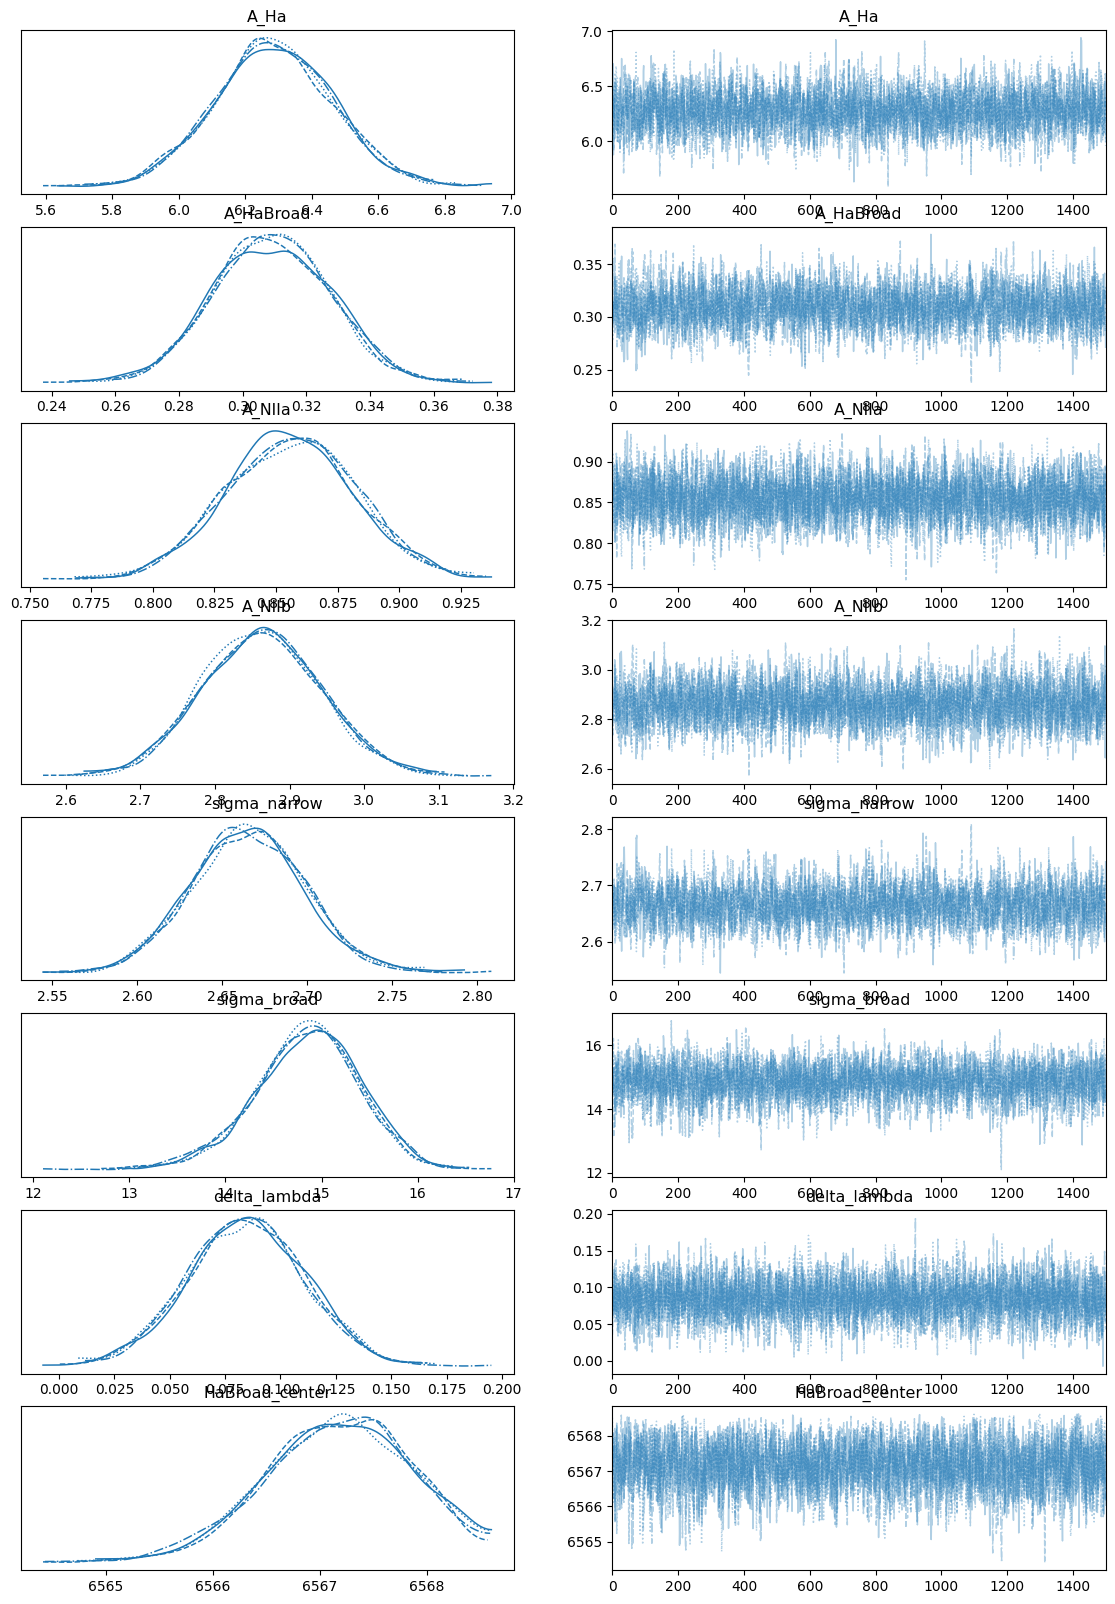

In [19]:
pm.plot_trace(trace, figsize= [14,20], divergences='bottom')
plt.show('off')


In [20]:
pm.summary(trace, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
A_Ha,6.29,0.18,5.96,6.62,0.00,0.00,3144.21,3436.08,1.0
A_HaBroad,0.31,0.02,0.28,0.34,0.00,0.00,2469.66,3561.34,1.0
A_NIIa,0.86,0.03,0.81,0.91,0.00,0.00,4227.81,4034.65,1.0
A_NIIb,2.86,0.08,2.71,3.01,0.00,0.00,2867.41,3452.12,1.0
sigma_narrow,2.67,0.03,2.60,2.73,0.00,0.00,2497.55,3032.41,1.0
sigma_broad,14.85,0.54,13.84,15.87,0.01,0.01,2968.14,3331.81,1.0
delta_lambda,0.08,0.03,0.04,0.13,0.00,0.00,4765.66,4215.07,1.0
HaBroad_center,6567.17,0.68,6565.94,6568.40,0.01,0.01,2554.85,2306.46,1.0


### How can we save the trace?

<font size='3'> We can use the library $\textbf{dill}$ to save the trace, the MAP, and the model in case you want to use the results without running the code all over again, this in order to not re-running the MCMC model again, as it can take a long time depending in the number of iterations you use.

In [22]:
# To save the trace
with open( 'MyTrace.dat', 'wb' ) as mcmc :
    dill.dump({'model': MyModel , 'trace': trace, 'map': map_estimate}, mcmc)

# Loading the trace    
with open( 'MyTrace.dat', 'rb' ) as mcmc:
    data = dill.load(mcmc)  
    
MyModel, trace, map_estimate = data['model'], data['trace'], data['map']

In [23]:
A_Ha = trace.posterior['A_Ha'].values
A_HaBroad  = trace.posterior['A_HaBroad'].values
A_NIIa = trace.posterior['A_NIIa'].values
A_NIIb = trace.posterior['A_NIIb'].values
sigma_narrow = trace.posterior['sigma_narrow'].values
sigma_broad = trace.posterior['sigma_broad'].values
HaBroad_center = trace.posterior['HaBroad_center'].values
delta_lambda = trace.posterior['delta_lambda'].values


In [24]:
trace.posterior.keys()

KeysView(<xarray.Dataset>
Dimensions:         (chain: 4, draw: 1500)
Coordinates:
  * chain           (chain) int64 0 1 2 3
  * draw            (draw) int64 0 1 2 3 4 5 6 ... 1494 1495 1496 1497 1498 1499
Data variables:
    A_Ha            (chain, draw) float64 6.234 6.069 6.705 ... 6.615 6.294
    A_HaBroad       (chain, draw) float64 0.3053 0.2995 0.3132 ... 0.3129 0.3285
    A_NIIa          (chain, draw) float64 0.8596 0.8707 0.8541 ... 0.8961 0.8314
    A_NIIb          (chain, draw) float64 2.889 2.897 2.93 ... 2.975 2.838 3.019
    sigma_narrow    (chain, draw) float64 2.67 2.656 2.622 ... 2.668 2.622 2.639
    sigma_broad     (chain, draw) float64 15.32 15.19 14.53 ... 14.42 15.7 14.09
    delta_lambda    (chain, draw) float64 0.07092 0.07719 ... 0.1159 0.09956
    HaBroad_center  (chain, draw) float64 6.568e+03 6.567e+03 ... 6.566e+03
Attributes:
    created_at:                 2025-04-01T17:26:38.629250
    arviz_version:              0.15.1
    inference_library:          pym

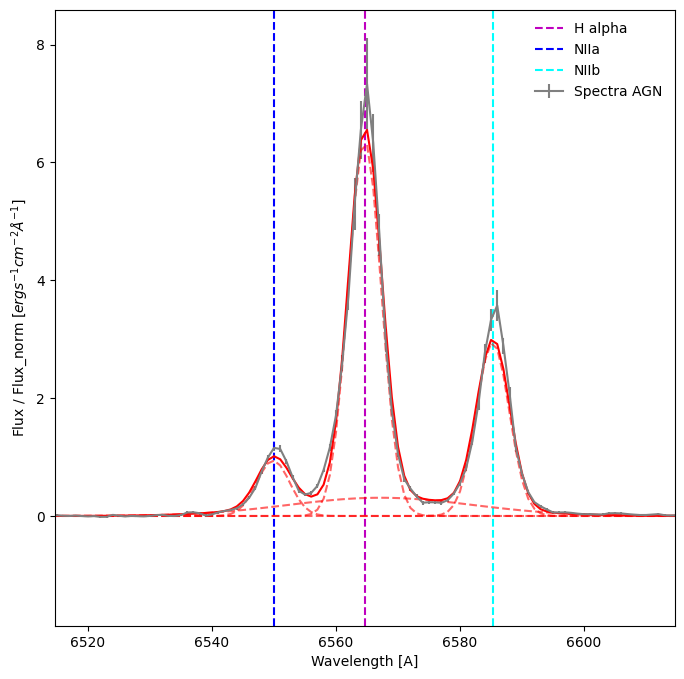

In [25]:
#z = 0.04466367

Ha_center = 6564.614
NIIa_center = 6549.86
NIIb_center = 6585.27

plt.figure(figsize=(8,8))
plt.errorbar(lamb, flux_sub, yerr = error_flux, color='gray', label='Spectra AGN')
plt.xlim(Ha_center - 50, Ha_center + 50)

delta_lamb = delta_lambda.mean()

plt.axvline(delta_lamb + Ha_center, ls ='--', label= 'H alpha', color='m')
plt.axvline(delta_lamb + NIIa_center, ls ='--', label= 'NIIa', color='blue')
plt.axvline(delta_lamb + NIIb_center, ls ='--', label= 'NIIb', color='cyan')

plt.plot(lamb, cuatruple_gaussian(lamb,  A_Ha.mean(), delta_lamb + Ha_center, sigma_narrow.mean(),  A_NIIa.mean(), delta_lamb + NIIa_center, A_NIIb.mean(), delta_lamb + NIIb_center, A_HaBroad.mean(), HaBroad_center.mean(),  sigma_broad.mean() ), color='r')
plt.plot(lamb, gaussian(lamb, delta_lamb +  A_Ha.mean(), Ha_center, sigma_narrow.mean() ), alpha=0.6, color='r', ls='--') #,  A_NIIa.mean(),NIIa_center, A_NIIb.mean(), NIIb_center, A_HaBroad.mean(), Ha_center,  sigma_broad.mean() ), color='r')
plt.plot(lamb, gaussian(lamb, A_HaBroad.mean(), HaBroad_center.mean(), sigma_broad.mean() ), alpha=0.6, color='r', ls='--') #,  A_NIIa.mean(),NIIa_center, A_NIIb.mean(), NIIb_center, A_HaBroad.mean(), Ha_center,  sigma_broad.mean() ), color='r')
plt.plot(lamb, gaussian(lamb, delta_lamb + A_NIIa.mean(), NIIa_center, sigma_narrow.mean() ), alpha=0.6, color='r', ls='--') #,  A_NIIa.mean(),NIIa_center, A_NIIb.mean(), NIIb_center, A_HaBroad.mean(), Ha_center,  sigma_broad.mean() ), color='r')
plt.plot(lamb, gaussian(lamb, delta_lamb + A_NIIb.mean(), NIIb_center, sigma_narrow.mean() ), alpha=0.6, color='r', ls='--') #,  A_NIIa.mean(),NIIa_center, A_NIIb.mean(), NIIb_center, A_HaBroad.mean(), Ha_center,  sigma_broad.mean() ), color='r')

plt.xlabel('Wavelength [A]')
plt.ylabel('Flux / Flux_norm [$erg s^{-1} cm^{-2} \\AA^{-1}$]')
plt.legend(frameon=False)

<ErrorbarContainer object of 3 artists>

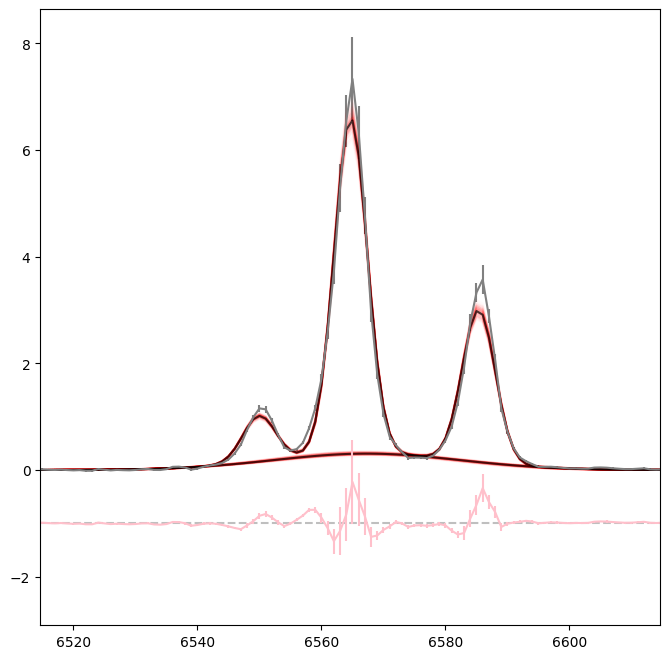

In [26]:
plt.figure(figsize=(8,8))
plt.errorbar(lamb, flux_sub, yerr = error_flux, color='gray', label='Spectra AGN')
plt.xlim(Ha_center - 50, Ha_center + 50)


for i in range(1300,1400):
    plt.plot(lamb, cuatruple_gaussian(lamb,  trace.posterior['A_Ha'].values[0][i], 
                                      trace.posterior['delta_lambda'].values[0][i] + Ha_center,
                                      trace.posterior['sigma_narrow'].values[0][i],  
                                      trace.posterior['A_NIIa'].values[0][i], 
                                      trace.posterior['delta_lambda'].values[0][i] + NIIa_center, 
                                      trace.posterior['A_NIIb'].values[0][i], 
                                      trace.posterior['delta_lambda'].values[0][i] + NIIb_center, 
                                      trace.posterior['A_HaBroad'].values[0][i], 
                                      trace.posterior['HaBroad_center'].values[0][i], 
                                      trace.posterior['sigma_broad'].values[0][i] ),
             color='r', alpha=0.02)
    plt.plot(lamb, gaussian(lamb, trace.posterior['A_HaBroad'].values[0][i], 
                            trace.posterior['HaBroad_center'].values[0][i], 
                            trace.posterior['sigma_broad'].values[0][i] ),
            color='r', alpha=0.02)
    
    
    

#MAP Plot
plt.plot(lamb, cuatruple_gaussian(lamb,  map_estimate['A_Ha'], 
                                      map_estimate['delta_lambda'] + Ha_center,
                                      map_estimate['sigma_narrow'],  
                                      map_estimate['A_NIIa'], 
                                      map_estimate['delta_lambda'] + NIIa_center, 
                                      map_estimate['A_NIIb'], 
                                      map_estimate['delta_lambda'] + NIIb_center, 
                                      map_estimate['A_HaBroad'], 
                                      map_estimate['HaBroad_center'], 
                                      map_estimate['sigma_broad']),
             color='k', alpha=0.7)
plt.plot(lamb, gaussian(lamb, map_estimate['A_HaBroad'], 
                            map_estimate['HaBroad_center'], 
                            map_estimate['sigma_broad'] ),
            color='k', alpha=0.7)


offset = 1.0


plt.axhline(-offset, ls='--', color='gray', alpha=0.5)
plt.errorbar(lamb,   flux_sub -  np.asarray(cuatruple_gaussian(lamb,  map_estimate['A_Ha'], 
                                      map_estimate['delta_lambda'] + Ha_center,
                                      map_estimate['sigma_narrow'],  
                                      map_estimate['A_NIIa'], 
                                      map_estimate['delta_lambda'] + NIIa_center, 
                                      map_estimate['A_NIIb'], 
                                      map_estimate['delta_lambda'] + NIIb_center, 
                                      map_estimate['A_HaBroad'], 
                                      map_estimate['HaBroad_center'], 
                                      map_estimate['sigma_broad'])) - offset,
         yerr = error_flux, color= 'pink')



### Corner plot

 <font size='3'> The corner plot shows all the one and two dimensional projections of the posterior probability distributions of your parameters. This is useful because it quickly demonstrates all of the covariances between parameters.

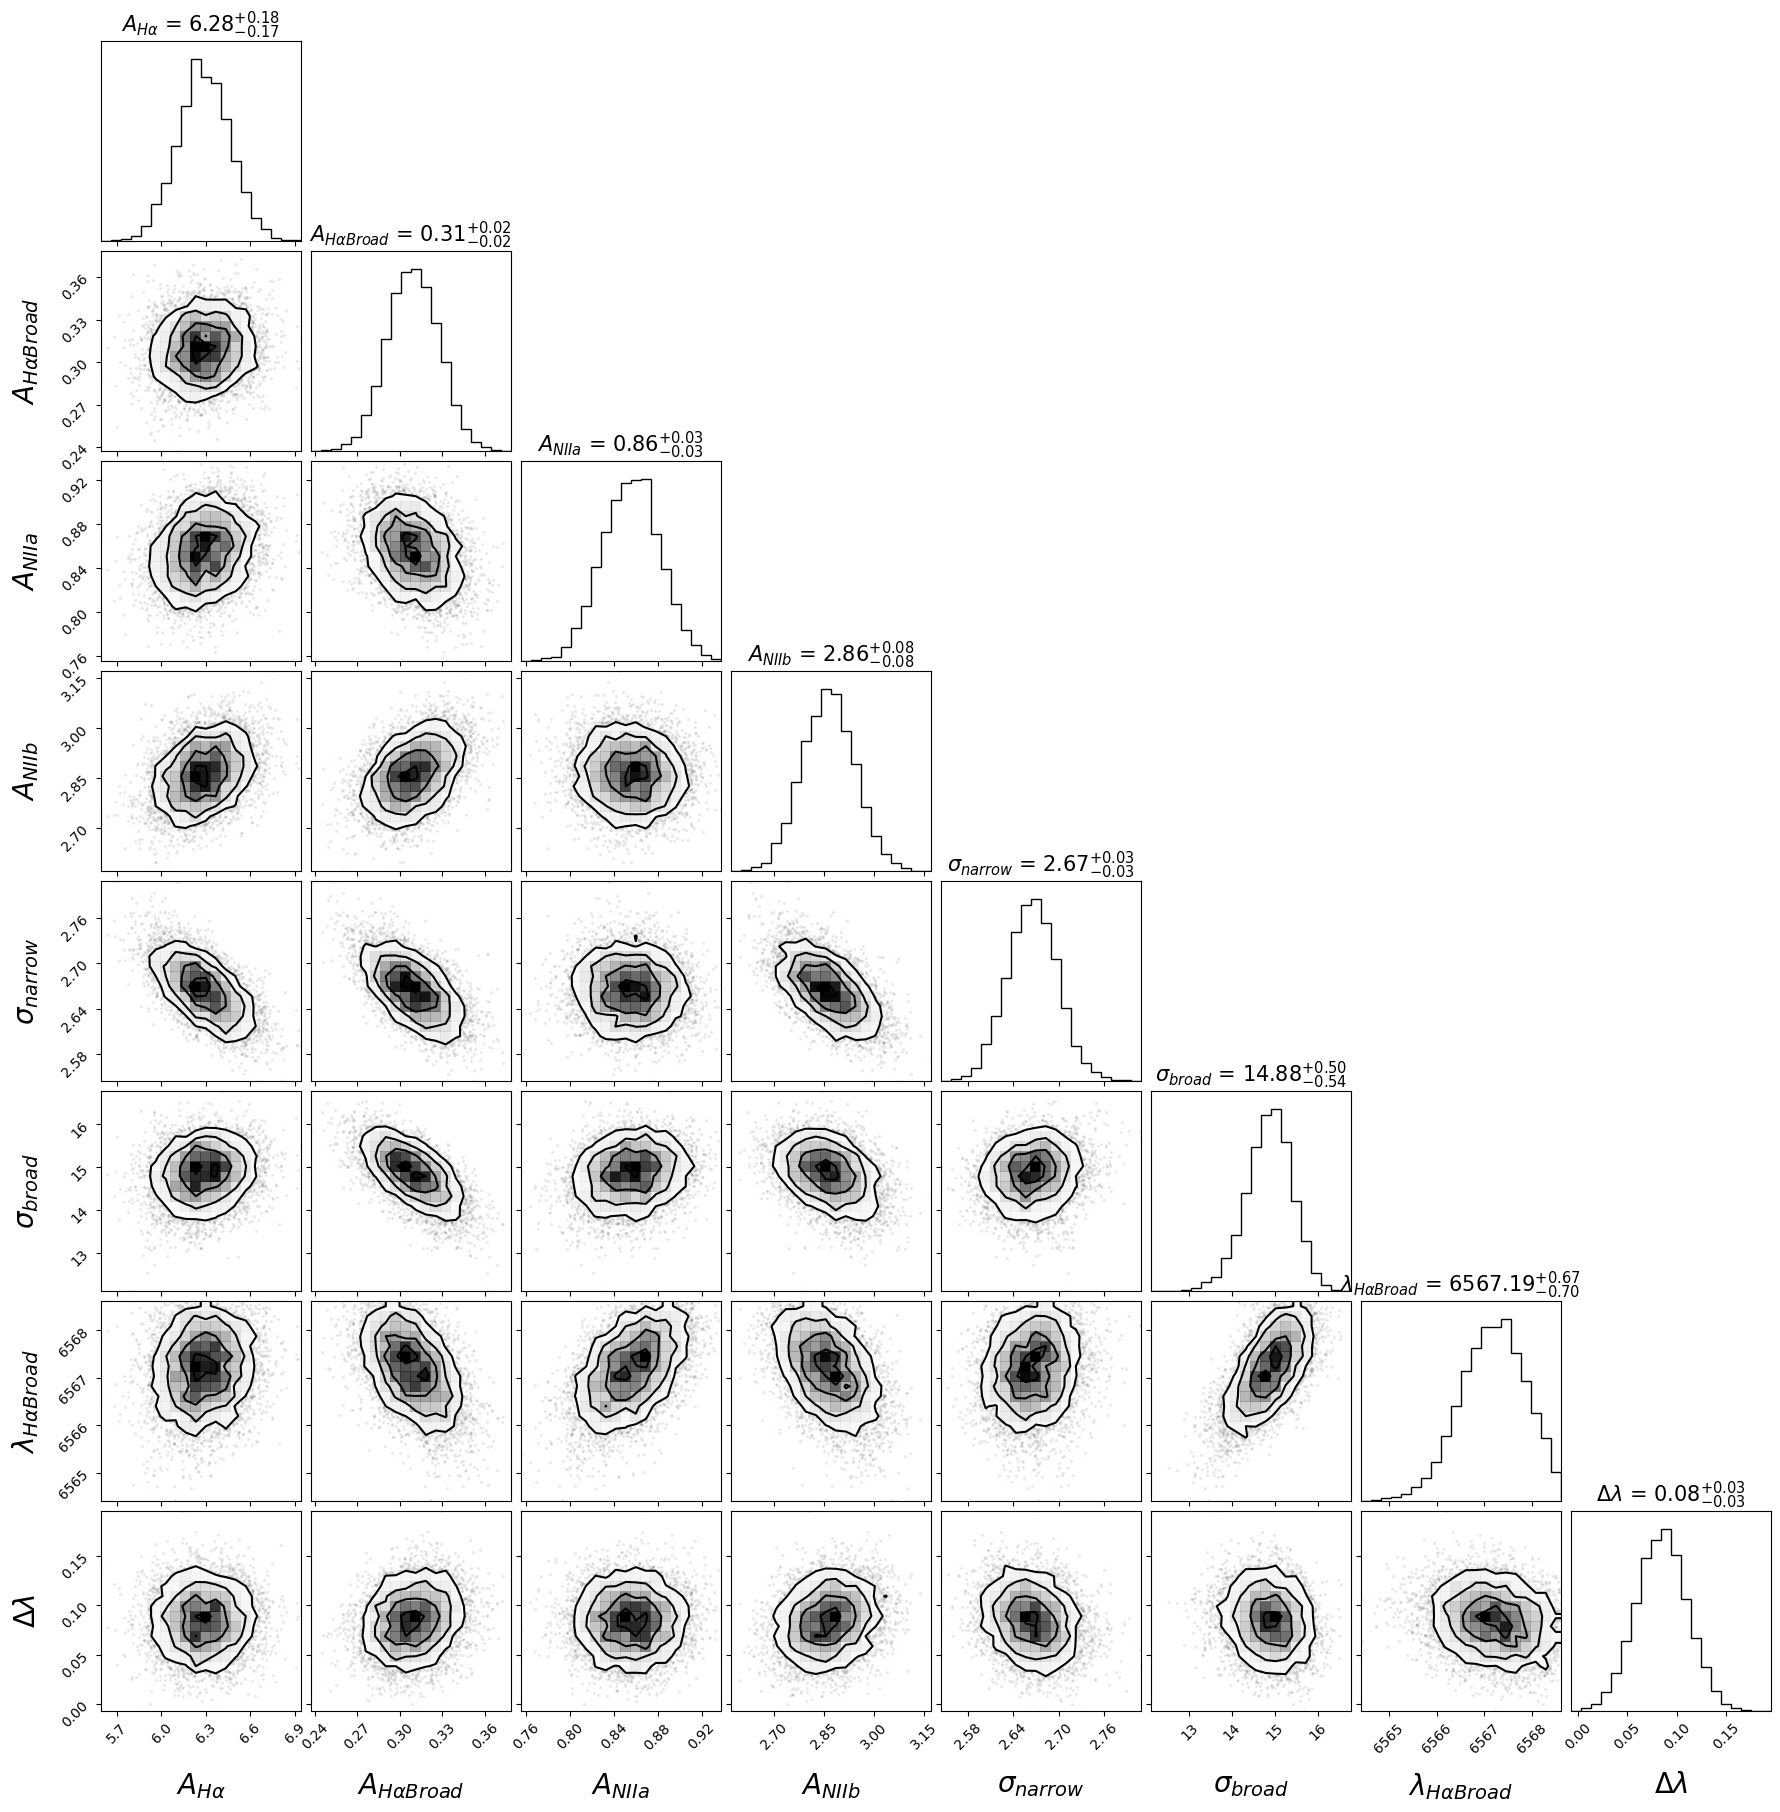

In [27]:
A_Ha = trace.posterior['A_Ha'].values
A_HaBroad  = trace.posterior['A_HaBroad'].values
A_NIIa = trace.posterior['A_NIIa'].values
A_NIIb = trace.posterior['A_NIIb'].values
sigma_narrow = trace.posterior['sigma_narrow'].values
sigma_broad = trace.posterior['sigma_broad'].values
HaBroad_center = trace.posterior['HaBroad_center'].values
delta_lambda = trace.posterior['delta_lambda'].values


A_Ha = np.array(A_Ha).T
A_HaBroad = np.array(A_HaBroad).T
A_NIIa = np.array(A_NIIa).T
A_NIIb = np.array(A_NIIb).T
sigma_narrow = np.array(sigma_narrow).T
sigma_broad = np.array(sigma_broad).T
HaBroad_center = np.array(HaBroad_center).T
delta_lambda = np.array(delta_lambda).T

samples = np.array([A_Ha, A_HaBroad, A_NIIa, A_NIIb, sigma_narrow, sigma_broad, HaBroad_center, delta_lambda]).T
labels = [r'$A_{H \alpha}$', r'$A_{H \alpha Broad}$', '$A_{NIIa}$', '$A_{NIIb}$', '$\sigma_{narrow}$',r'$\sigma_{broad}$', r'$\lambda_{H \alpha Broad}$', r'$\Delta \lambda$']

figure = corner.corner(samples, labels=labels, show_titles=True, title_kwargs={"fontsize": 15}, label_kwargs={"fontsize":20})


 <font size='3'> Since we detected and fitted a broad component in $H\alpha$, we can derive an estimate of the BH mass for this AGN!. And for that we will use an emprically derived formulae from Reines et al. 2013, which requires the luminosity of Broad Halpha, as well as the width of the broad line.

\begin{equation}

    log \left( \frac{M_{BH}}{M_{\odot}} \right) = log \epsilon + 6.57 + 0.47 log \left( \frac{L_{H \alpha}}{10^{42} erg s^{-1}} \right) + 2.06 log \left( \frac{FWHM_{H \alpha}}{10^3 km s^{-1}} \right)
    
\end{equation}
    
<font size='3'> 
    
    
<font size='3'> Because we used a gaussian, we know that the integral is: 

\begin{equation}
    \int_{0}^{\inf} A_{H \alpha broad} e^{-(\lambda - \lambda_{H \alpha Broad})/2\sigma_{broad}^2} d \lambda = A_{H \alpha broad} \sigma_{H \alpha broad} \sqrt{2 \pi}
\end{equation}


 <font size='3'> Hence we can get the posterior of the integral as:

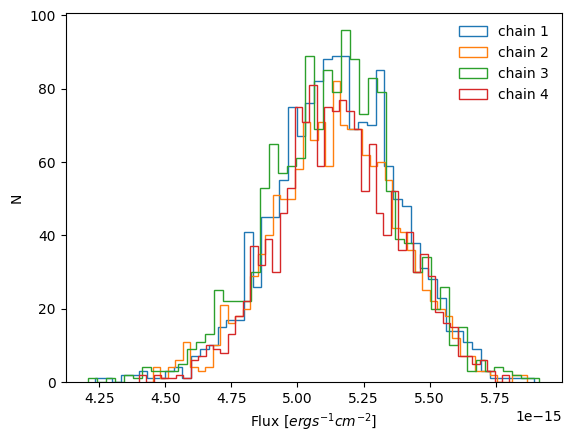

In [28]:
chains=4
HaBC_flux = []

for i in range(chains):
    
    
    HaBC_flux.append(flux_norm * A_HaBroad[:,i] * sigma_broad[:,i] * u.Angstrom * (2 * np.pi)**(0.5))
    
    plt.hist(HaBC_flux[-1], label='chain {}'.format(i+1), histtype='step', bins=50)

plt.legend(frameon=False)
plt.xlabel('Flux [$erg s^{-1} cm^{-2}$]')
plt.ylabel('N')
plt.show()


In [158]:
HaBC_flux[0]

<Quantity [514.54385352, 543.0486693 , 509.68096307, ..., 515.01539549,
           528.3413086 , 517.68470067] erg / (cm2 s)>

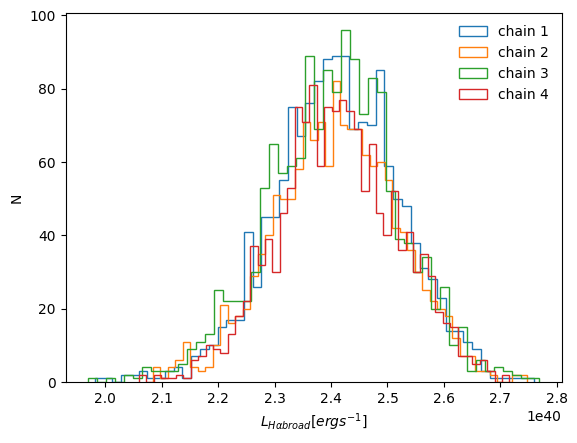

In [29]:


# Cosmo
z = 0.04466367
Ho = 70
OmegaM = 0.3

cos = astropy.cosmology.FlatLambdaCDM(Ho, OmegaM)
dL = cos.luminosity_distance(z)
dL = dL.to(u.cm)
L_HaBC = []


for i in range(chains):
    

    L_HaBC.append((4 * np.pi * dL**2 * HaBC_flux[i]).to(u.erg/u.s))
    
    plt.hist(L_HaBC[-1], label='chain {}'.format(i+1), histtype='step', bins=50)
    
#L_HaBC

plt.legend(frameon=False)
plt.xlabel(r'$L_{ H \alpha broad} [erg s^{-1}]$')
plt.ylabel('N')
plt.show()


In [30]:
def Mass_calculator(Sigma, Sigma_err, L, L_err, P, P_err):
    """
    Calculates the Mass of the BH from the FWHM and Luminosity of the broad Halpha line
    
    Formula derived empirically by Reines et al. 2013
    
    ======
    Input:
    ======
    Sigma : [float] Std of gaussian fitting the Broad component # in Angstrom 
    Sigma_err: [float] Std error of gaussian fitting the Broad Component # in Angstrom
    L : [float] List of the luminosities # in erg/s
    L_err : [float] Position error of Broad Component # in erg/s
    P : [float] Position of Broad Component # in Angstrom
    P_err: [float] Position error of Broad Component # in Angstrom 
    -----------------------------------------
    ======
    Output:
    ======
    A list with the following elements:
    
    mass : [float] logarithmic BH mass in solar mass units 
    mass_error : [float] log Error of estimated mass
    v : [float] Velocity in km/s from the broad line
    v_error : [float] Error velocity in km/s from the broad line 
    """
    # light speed in km/s
    c = 299792.458  
    
    FWHM = 2.355 * Sigma # find FWHM
    v = FWHM * c / P # calculate velocity asociated to FWHM
    FWHM_err = 2.355 * Sigma_err # calculate FWHM error
    
    v_err = (P_err**2 * (FWHM * c / P**2)**2  +  FWHM_err**2 * (c / P)**2 )**(1/2) # velocity error
    
    mass = 6.57 + 0.47 * np.log10(L / 10**42) + 2.06 * np.log10(v / 10**3) # mass formula
    mass_err = ((2.06 * (v_err / v) / np.log(10))**2 + (0.47  * L_err/L /np.log(10))**2)**(1/2) #mass error
    
    return [mass, mass_err, v, v_err]

In [31]:
L_HaBC = np.asarray(L_HaBC)

Mass_calculator(sigma_broad.mean(), sigma_broad.std(), L_HaBC.mean(), L_HaBC.std(), HaBroad_center.mean(), HaBroad_center.std())

[6.227915518523539,
 0.033843811568272396,
 1596.3862322238506,
 58.03119296498416]

<font size='3'> Finally, we are able to estimate that the AGN in J100903.23-001337.4. is powered by a BH of mass:

\begin{equation}
 log(M_{BH}/M_{\odot}) = 6.228 \pm 0.0346
\end{equation}

<font size='3'> A slightly smaller BH than the one found in our own Galactic center :-)
